# 04 - Explainable AI (XAI) & Knowledge-Based System
## Dataset FAR-Trans: Transparent Investment Intention Analysis

**Penulis:** Naufal Rizki Abyan (23082010235)  
**Program:** Magang Riset - Transparent Investment Intention Analysis  
**Notebook:** 04/05 (Explainability - MK SPK)

---

## Tujuan Notebook

Notebook ini adalah **signature contribution** dari penelitian — mengimplementasi **dua layer transparency** yang bekerja bersama:

1. **SHAP (Shapley Additive exPlanations)** — Statistical explanation layer
   - Global feature attribution (mana fitur paling berpengaruh secara umum)
   - Local explanation (kenapa customer X diprediksi Y)
   - Feature interaction analysis
   
2. **Knowledge-Based System (KBS) Rules** — Domain knowledge layer
   - 15 if-then rules berbasis teori finansial (MPT, Behavioral Finance, MiFID II)
   - Natural language explanation
   - Cross-validation dengan SHAP output

## Pendekatan Hybrid Transparency

Kombinasi SHAP + KBS memberikan **transparency yang superior** dibanding pakai satu metode saja:

| Aspek | SHAP saja | KBS saja | **SHAP + KBS** |
|-------|-----------|----------|----------------|
| Akurasi statistik | ✓ | ✗ | ✓ |
| Bahasa awam | ✗ | ✓ | ✓ |
| Referensi akademis | ✗ | ✓ | ✓ |
| Reliability check | ✗ | ✗ | ✓ |
| Dashboard-ready | sebagian | ✓ | ✓ |

## Output Tersimpan

Notebook ini menghasilkan artefak yang akan dipakai langsung di **dashboard (notebook 05)**:
- `models/shap_explainer.pkl` — SHAP explainer untuk real-time inference
- `models/shap_values_test.npy` — Pre-computed SHAP values untuk test set
- `src/kbs/rules.py` — Importable KBS rules engine
- `reports/figures/xai/` — Semua visualisasi SHAP
- `reports/kbs_rules_documentation.md` — Dokumentasi 15 rules dengan referensi

---
## 1. Setup & Load Trained Model

Load best model dari notebook 03, beserta LabelEncoder dan processed data.

In [1]:
# Setup
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

# SHAP
import shap

# Paths
PROCESSED_DIR = project_root / 'data' / 'processed'
MODEL_DIR = project_root / 'models'
REPORT_DIR = project_root / 'reports'
FIG_DIR = REPORT_DIR / 'figures' / 'xai'
KBS_DIR = project_root / 'src' / 'kbs'

FIG_DIR.mkdir(parents=True, exist_ok=True)
KBS_DIR.mkdir(parents=True, exist_ok=True)

# Settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
sns.set_style('whitegrid')

print(f"Project root: {project_root}")
print(f"SHAP version: {shap.__version__}")
print(f"Figures dir: {FIG_DIR}")

Project root: C:\All Projects\Transparent Investment Intentions Dashboard
SHAP version: 0.51.0
Figures dir: C:\All Projects\Transparent Investment Intentions Dashboard\reports\figures\xai


In [2]:
# Load model, encoder, dan data
best_model = joblib.load(MODEL_DIR / 'best_model.pkl')
le_target = joblib.load(MODEL_DIR / 'label_encoder.pkl')

X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').values.ravel()
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').values.ravel()

label_names = list(le_target.classes_)
feature_names = X_train.columns.tolist()

print(f"Model: {type(best_model).__name__}")
print(f"Classes ({len(label_names)}): {label_names}")
print(f"Features ({len(feature_names)})")
print(f"Test set: {X_test.shape}")

Model: RandomForestClassifier
Classes (4): [np.str_('Aggressive'), np.str_('Balanced'), np.str_('Conservative'), np.str_('Income')]
Features (33)
Test set: (2723, 33)


---
## 2. SHAP Explainer Initialization

### Apa itu SHAP?

**SHAP (Shapley Additive exPlanations)** adalah metode XAI berbasis **Shapley values** dari cooperative game theory (Lundberg & Lee, 2017). Untuk setiap prediksi, SHAP menghitung kontribusi setiap fitur secara matematis konsisten dengan 3 properti penting:

1. **Local accuracy**: Sum of SHAP values = prediction - expected value
2. **Missingness**: Feature absent → SHAP value = 0
3. **Consistency**: Jika kontribusi feature naik, SHAP value tidak boleh turun

### Pemilihan Explainer

Untuk **tree-based models** (Random Forest, XGBoost), kita pakai `TreeExplainer` yang:
- **Eksak** (bukan approximation)
- **Sangat cepat** (polynomial time complexity)
- Memberikan **interventional SHAP values** by default

Untuk model lain (linear, neural network), pakai `KernelExplainer` atau `DeepExplainer`.

In [3]:
# Initialize SHAP TreeExplainer
print("Initializing SHAP TreeExplainer...")
explainer = shap.TreeExplainer(best_model)
print("✓ Explainer ready")

# Untuk efisiensi, gunakan sample dari test set untuk SHAP computation
# (200 samples cukup untuk insight global yang stable)
N_SAMPLE = 200
sample_idx = np.random.RandomState(42).choice(len(X_test), N_SAMPLE, replace=False)
X_sample = X_test.iloc[sample_idx].copy()
y_sample = y_test[sample_idx]

print(f"\nSample size for SHAP analysis: {N_SAMPLE}")
print(f"Sample target distribution:")
for cls, name in enumerate(label_names):
    count = (y_sample == cls).sum()
    print(f"  {name}: {count}")

Initializing SHAP TreeExplainer...
✓ Explainer ready

Sample size for SHAP analysis: 200
Sample target distribution:
  Aggressive: 17
  Balanced: 64
  Conservative: 26
  Income: 93


In [4]:
# Compute SHAP values
# Untuk multi-class, shap_values adalah list dengan length = n_classes
print("Computing SHAP values (might take 30-60 seconds)...")

import time
start = time.time()
shap_values = explainer.shap_values(X_sample)
elapsed = time.time() - start

# Handle different SHAP versions
# Newer versions return array of shape (n_samples, n_features, n_classes)
# Older versions return list of arrays
if isinstance(shap_values, list):
    print(f"✓ SHAP values computed in {elapsed:.1f}s")
    print(f"  Format: List of {len(shap_values)} arrays (one per class)")
    print(f"  Each array shape: {shap_values[0].shape}")
    # Convert to consistent 3D format for processing
    shap_values_3d = np.stack(shap_values, axis=-1)
else:
    print(f"✓ SHAP values computed in {elapsed:.1f}s")
    print(f"  Format: 3D array")
    print(f"  Shape: {shap_values.shape} (n_samples, n_features, n_classes)")
    shap_values_3d = shap_values

print(f"\nFinal 3D shape: {shap_values_3d.shape}")

Computing SHAP values (might take 30-60 seconds)...
✓ SHAP values computed in 55.8s
  Format: 3D array
  Shape: (200, 33, 4) (n_samples, n_features, n_classes)

Final 3D shape: (200, 33, 4)


---
## 3. SHAP Global Analysis

### Pertanyaan yang Dijawab
- Fitur mana yang **paling penting** secara keseluruhan?
- Bagaimana **kontribusi fitur** per kelas?
- Apakah konsisten dengan **feature importance** dari Random Forest?

In [5]:
# Global Feature Importance (mean absolute SHAP across all samples & classes)
mean_abs_shap = np.abs(shap_values_3d).mean(axis=0).mean(axis=-1)
feat_importance_shap = pd.Series(mean_abs_shap, index=feature_names).sort_values(ascending=False)

print("Top 15 Features by Mean |SHAP| (Global Importance):")
print("="*60)
for i, (feat, val) in enumerate(feat_importance_shap.head(15).items(), 1):
    print(f"  {i:2d}. {feat:45s} {val:.4f}")

Top 15 Features by Mean |SHAP| (Global Importance):
   1. investmentCapacity                            0.0436
   2. digital_ratio                                 0.0315
   3. buy_ratio                                     0.0242
   4. preferred_channel_Internet Banking            0.0228
   5. total_invested                                0.0167
   6. customerType_Mass                             0.0147
   7. avg_days_between_transactions                 0.0107
   8. total_sold                                    0.0101
   9. dominant_sector_Communication Services        0.0094
  10. buy_count                                     0.0090
  11. log_avg_value                                 0.0088
  12. sell_to_buy_value_ratio                       0.0085
  13. avg_transaction_value                         0.0085
  14. investment_period_days                        0.0072
  15. total_transactions                            0.0056


[SAVED] shap_global_importance.png


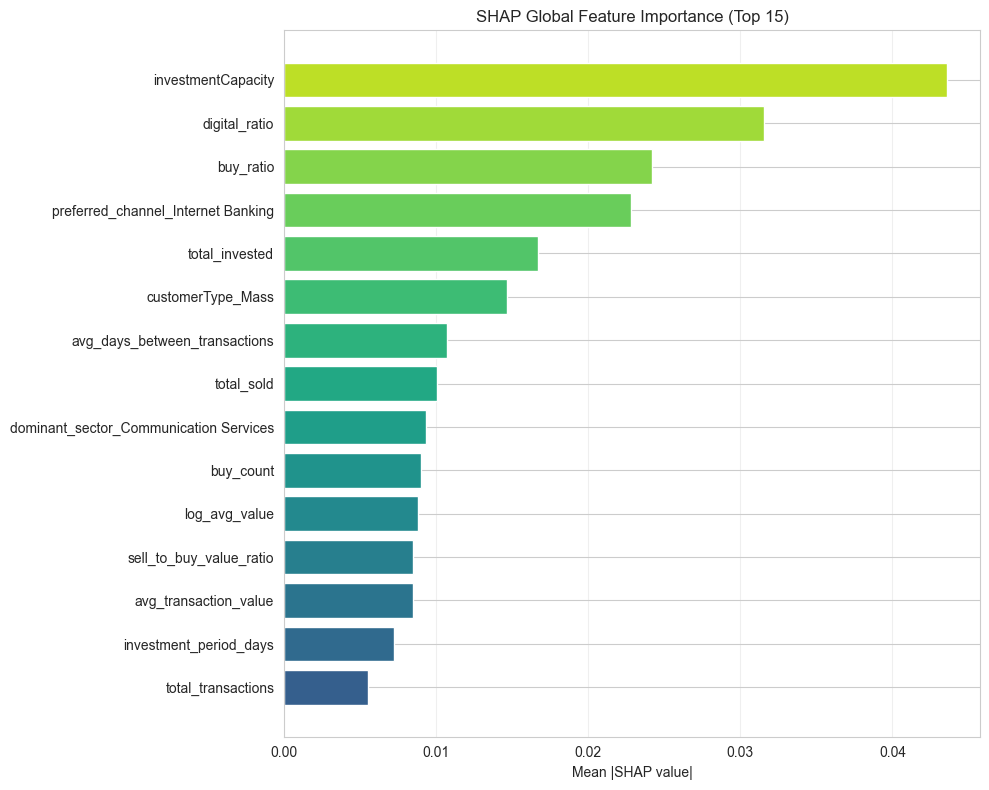

In [6]:
# Plot 1: Global Bar Plot (Top 15)
fig, ax = plt.subplots(figsize=(10, 8))

top_15 = feat_importance_shap.head(15)
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_15)))
ax.barh(range(len(top_15)), top_15.values[::-1], color=colors)
ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15.index.tolist()[::-1])
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Global Feature Importance (Top 15)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_global_importance.png')
print(f"[SAVED] shap_global_importance.png")
plt.show()

[SAVED] shap_summary_per_class.png


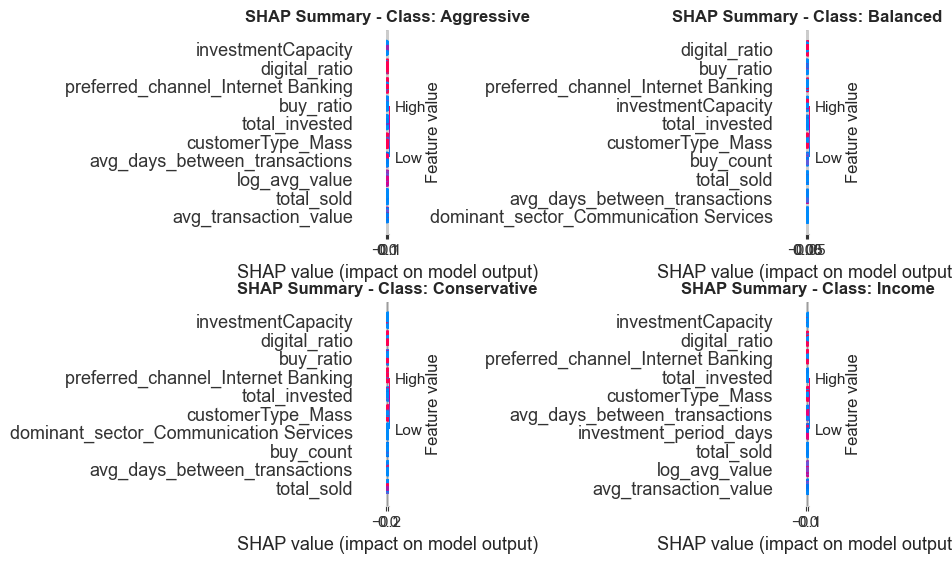

In [7]:
# Plot 2: SHAP Summary Plot per class (beeswarm)
# Untuk setiap kelas, tampilkan distribusi SHAP values

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for cls_idx, cls_name in enumerate(label_names):
    plt.sca(axes[cls_idx])
    
    # Extract SHAP values untuk class ini
    if isinstance(shap_values, list):
        sv_class = shap_values[cls_idx]
    else:
        sv_class = shap_values_3d[:, :, cls_idx]
    
    # Plot summary for this class
    shap.summary_plot(sv_class, X_sample, 
                      feature_names=feature_names,
                      plot_type='dot',
                      max_display=10,
                      show=False)
    plt.title(f'SHAP Summary - Class: {cls_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_summary_per_class.png')
print(f"[SAVED] shap_summary_per_class.png")
plt.show()

[SAVED] shap_vs_rf_importance.png


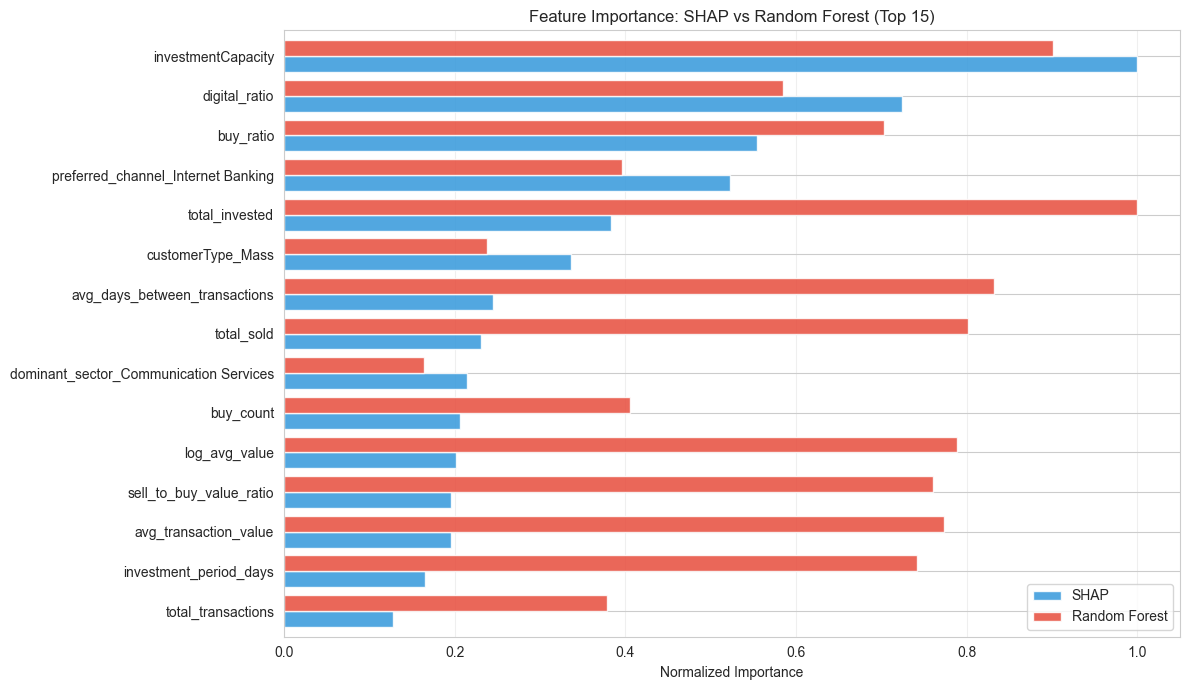


Spearman correlation SHAP vs RF importance: 0.6370 (p=6.71e-05)
[!] Moderate agreement — perlu investigasi feature interaction


In [8]:
# Plot 3: Komparasi Feature Importance — SHAP vs Random Forest built-in
rf_importance = pd.Series(best_model.feature_importances_, index=feature_names)

# Normalisasi ke skala 0-1 untuk perbandingan
shap_norm = feat_importance_shap / feat_importance_shap.max()
rf_norm = rf_importance / rf_importance.max()

# Ambil top 15 dari SHAP, bandingkan dengan RF
top_15_features = feat_importance_shap.head(15).index.tolist()
comparison = pd.DataFrame({
    'SHAP': shap_norm.loc[top_15_features],
    'Random Forest': rf_norm.loc[top_15_features]
})

fig, ax = plt.subplots(figsize=(12, 7))
comparison[::-1].plot(kind='barh', ax=ax, width=0.8, 
                       color=['#3498db', '#e74c3c'], alpha=0.85)
ax.set_xlabel('Normalized Importance')
ax.set_title('Feature Importance: SHAP vs Random Forest (Top 15)')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_vs_rf_importance.png')
print(f"[SAVED] shap_vs_rf_importance.png")
plt.show()

# Hitung Spearman correlation untuk validasi konsistensi
from scipy.stats import spearmanr
corr, p_val = spearmanr(shap_norm.values, rf_norm.values)
print(f"\nSpearman correlation SHAP vs RF importance: {corr:.4f} (p={p_val:.2e})")
if corr > 0.7:
    print(f"✓ Strong agreement between SHAP and RF importance — explanations are CONSISTENT")
else:
    print(f"[!] Moderate agreement — perlu investigasi feature interaction")

---
## 4. SHAP Local Analysis

### Pertanyaan yang Dijawab
- **Mengapa** model memprediksi customer ini sebagai Risk Level X?
- Fitur mana yang **paling kontributif** untuk prediksi tersebut?
- Apakah ada **fitur yang menentang** prediksi?

Local analysis adalah **kunci transparency** untuk individual investors di dashboard.

In [9]:
# Helper function untuk waterfall plot per sample
def plot_local_explanation(sample_idx_in_xtest, save_name=None):
    """Plot waterfall SHAP untuk 1 customer dari test set."""
    # Dapatkan posisi di X_sample (yang sudah di-subsample)
    if sample_idx_in_xtest >= len(X_sample):
        # Refit jika sample tidak ada di subset
        return None
    
    # Predict
    X_one = X_sample.iloc[[sample_idx_in_xtest]]
    pred = best_model.predict(X_one)[0]
    proba = best_model.predict_proba(X_one)[0]
    pred_class = label_names[pred]
    true_class = label_names[y_sample[sample_idx_in_xtest]]
    
    # Get SHAP values untuk predicted class
    if isinstance(shap_values, list):
        sv = shap_values[pred][sample_idx_in_xtest]
        expected_val = explainer.expected_value[pred]
    else:
        sv = shap_values_3d[sample_idx_in_xtest, :, pred]
        expected_val = explainer.expected_value[pred] if hasattr(explainer.expected_value, '__len__') else explainer.expected_value
    
    # Build SHAP Explanation object untuk waterfall
    explanation = shap.Explanation(
        values=sv,
        base_values=expected_val,
        data=X_one.values[0],
        feature_names=feature_names
    )
    
    # Waterfall plot
    fig = plt.figure(figsize=(10, 7))
    shap.waterfall_plot(explanation, max_display=12, show=False)
    plt.title(f'Customer #{sample_idx_in_xtest} | True: {true_class} | Predicted: {pred_class} ({proba[pred]:.1%})',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    
    if save_name:
        plt.savefig(FIG_DIR / save_name)
        print(f"  [SAVED] {save_name}")
    plt.show()
    
    return {
        'sample_idx': sample_idx_in_xtest,
        'true_class': true_class,
        'predicted_class': pred_class,
        'confidence': proba[pred],
        'shap_values': sv,
        'feature_names': feature_names
    }

# Pilih 4 sample - satu per kelas - untuk demonstrasi
print("Local Explanation untuk 4 sample (satu per kelas):")
print("="*70)

# Cari satu sample untuk setiap kelas yang prediksinya benar
selected_samples = {}
for cls_idx, cls_name in enumerate(label_names):
    # Find samples yang true label = cls_idx DAN predicted = cls_idx (correct)
    pred_sample = best_model.predict(X_sample.values)
    correct_idx = np.where((y_sample == cls_idx) & (pred_sample == cls_idx))[0]
    if len(correct_idx) > 0:
        selected_samples[cls_name] = correct_idx[0]
    else:
        # Fallback: ambil sample mana saja dengan true label cls_idx
        any_idx = np.where(y_sample == cls_idx)[0]
        if len(any_idx) > 0:
            selected_samples[cls_name] = any_idx[0]

print(f"Selected samples: {selected_samples}")

Local Explanation untuk 4 sample (satu per kelas):
Selected samples: {np.str_('Aggressive'): np.int64(15), np.str_('Balanced'): np.int64(3), np.str_('Conservative'): np.int64(19), np.str_('Income'): np.int64(8)}



--- Aggressive (sample #15) ---
  [SAVED] shap_waterfall_aggressive.png


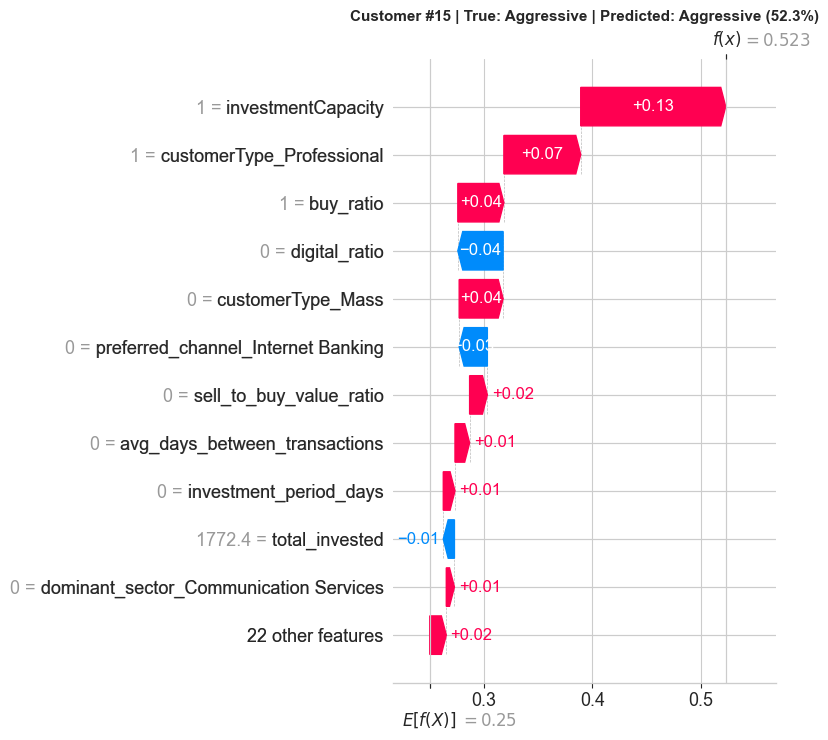

Top 5 contributing features:
  + investmentCapacity: SHAP=0.1335
  + customerType_Professional: SHAP=0.0708
  + buy_ratio: SHAP=0.0424
  - digital_ratio: SHAP=-0.0417
  + customerType_Mass: SHAP=0.0405

--- Balanced (sample #3) ---
  [SAVED] shap_waterfall_balanced.png


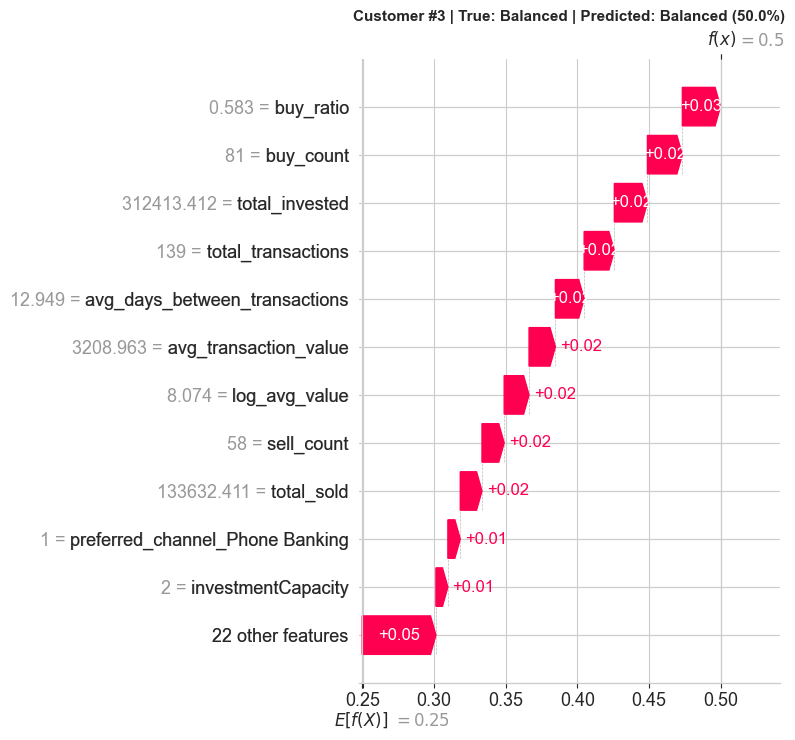

Top 5 contributing features:
  + buy_ratio: SHAP=0.0266
  + buy_count: SHAP=0.0244
  + total_invested: SHAP=0.0231
  + total_transactions: SHAP=0.0211
  + avg_days_between_transactions: SHAP=0.0201

--- Conservative (sample #19) ---
  [SAVED] shap_waterfall_conservative.png


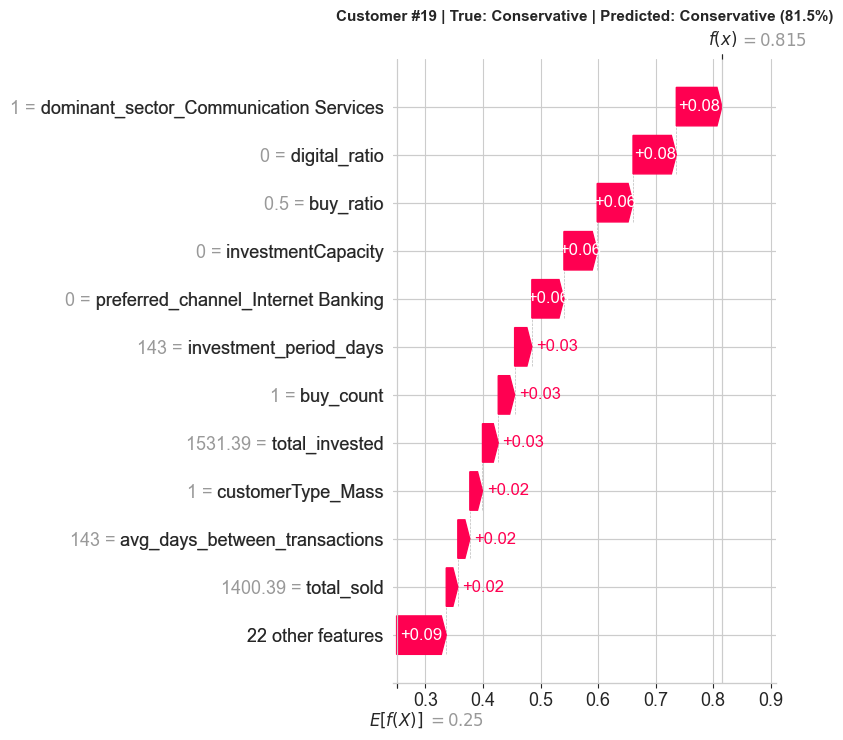

Top 5 contributing features:
  + dominant_sector_Communication Services: SHAP=0.0793
  + digital_ratio: SHAP=0.0752
  + buy_ratio: SHAP=0.0623
  + investmentCapacity: SHAP=0.0578
  + preferred_channel_Internet Banking: SHAP=0.0558

--- Income (sample #8) ---
  [SAVED] shap_waterfall_income.png


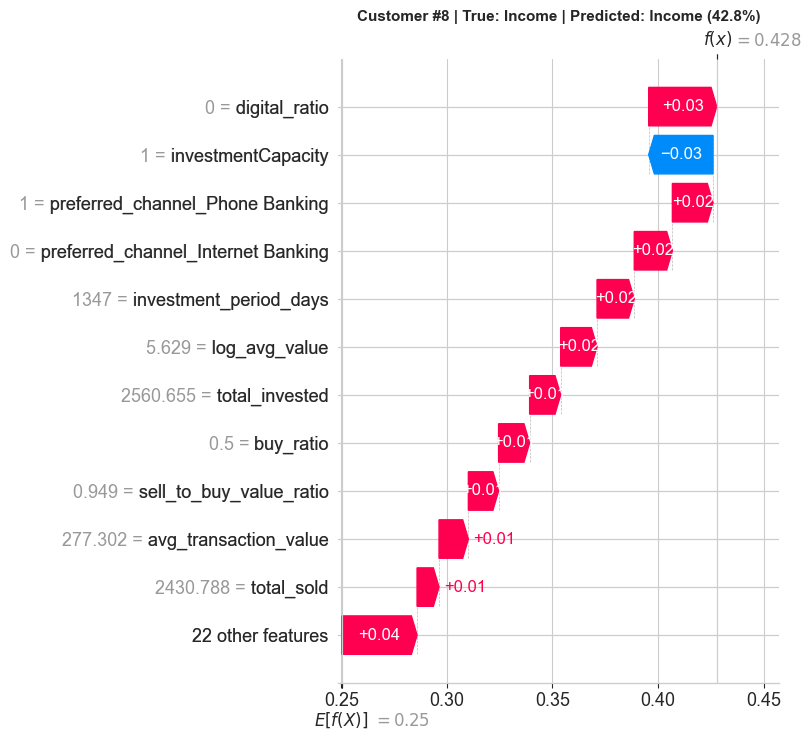

Top 5 contributing features:
  + digital_ratio: SHAP=0.0322
  - investmentCapacity: SHAP=-0.0305
  + preferred_channel_Phone Banking: SHAP=0.0192
  + preferred_channel_Internet Banking: SHAP=0.0180
  + investment_period_days: SHAP=0.0176


In [10]:
# Generate waterfall plots untuk 4 sample
local_results = []
for cls_name, idx in selected_samples.items():
    print(f"\n--- {cls_name} (sample #{idx}) ---")
    safe_name = cls_name.lower()
    result = plot_local_explanation(idx, save_name=f'shap_waterfall_{safe_name}.png')
    if result:
        local_results.append(result)
        
        # Print top contributing features
        sv_abs = np.abs(result['shap_values'])
        top_5_idx = np.argsort(sv_abs)[::-1][:5]
        print(f"Top 5 contributing features:")
        for i in top_5_idx:
            sign = '+' if result['shap_values'][i] > 0 else '-'
            print(f"  {sign} {feature_names[i]}: SHAP={result['shap_values'][i]:.4f}")

---
## 5. Feature Interaction Analysis

### Pertanyaan yang Dijawab
Bagaimana fitur-fitur **berinteraksi** dalam menentukan prediksi?
Misalnya: apakah pengaruh `total_invested` bergantung pada `investmentCapacity`?

SHAP **dependence plot** menjawab ini dengan menampilkan SHAP value vs feature value, dengan color encoding fitur kedua (paling correlated).

Top 4 features for dependence analysis: ['investmentCapacity', 'digital_ratio', 'buy_ratio', 'preferred_channel_Internet Banking']
[SAVED] shap_dependence_plots.png


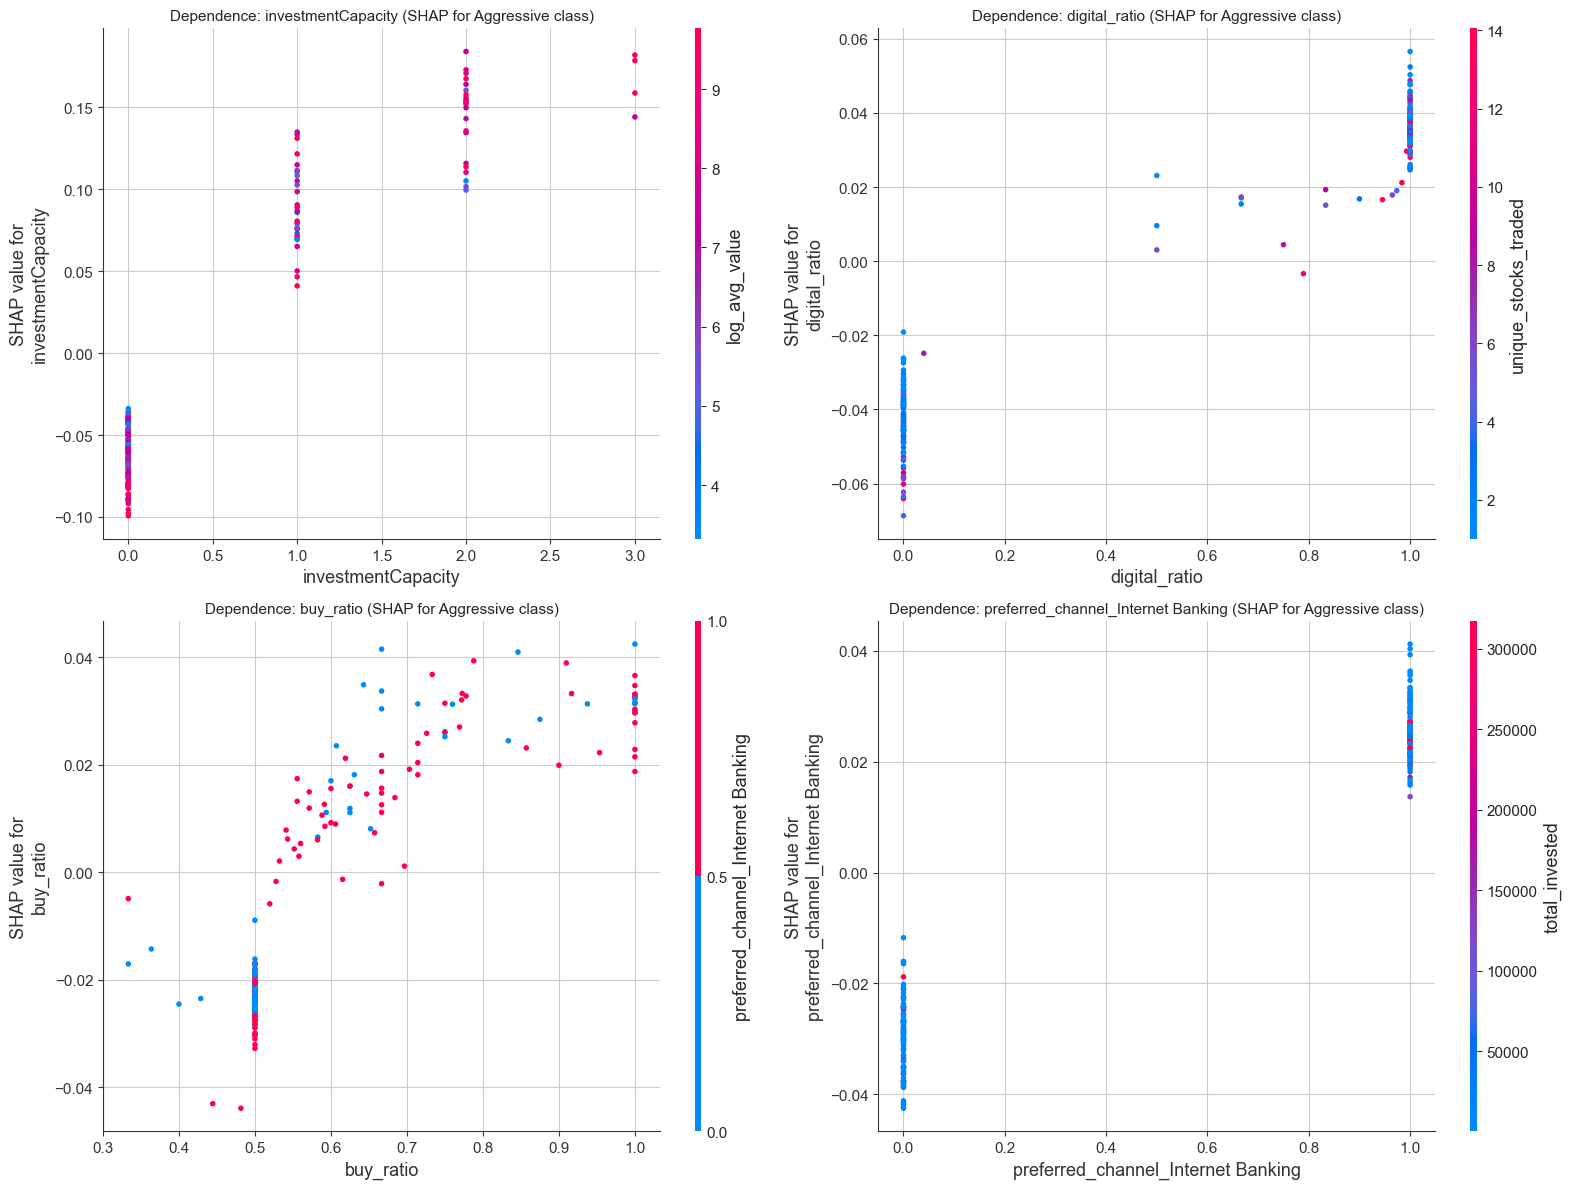

In [11]:
# Plot dependence untuk top 4 features
top_features_for_dependence = feat_importance_shap.head(4).index.tolist()
print(f"Top 4 features for dependence analysis: {top_features_for_dependence}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Pakai SHAP values untuk class Aggressive (paling discriminative)
class_aggressive = label_names.index('Aggressive')
if isinstance(shap_values, list):
    sv_aggressive = shap_values[class_aggressive]
else:
    sv_aggressive = shap_values_3d[:, :, class_aggressive]

for i, feat in enumerate(top_features_for_dependence):
    plt.sca(axes[i])
    shap.dependence_plot(
        feat, sv_aggressive, X_sample, 
        feature_names=feature_names,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'Dependence: {feat} (SHAP for Aggressive class)', fontsize=11)

plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_dependence_plots.png')
print(f"[SAVED] shap_dependence_plots.png")
plt.show()

---
## 6. Knowledge-Based System (KBS) Rules

### Filosofi Pendekatan

Sementara SHAP memberikan **statistical explanation**, KBS memberikan **domain knowledge explanation**. Keduanya bekerja sinergis:

- **SHAP**: "Feature X mengontribusi +0.15 ke prediksi Aggressive"
- **KBS**: "Karena customer punya capacity tinggi (>300K EUR) + portfolio diversifikasi (5+ stocks), Modern Portfolio Theory mendukung profil Aggressive"

### Struktur 15 Rules

Rules dikelompokkan dalam **5 kategori** berbasis teori finansial dan regulasi:

1. **Capacity Assessment** (4 rules) — Berdasarkan MiFID II Article 25
2. **Trading Behavior** (4 rules) — Berdasarkan Behavioral Finance (Shefrin & Statman, 1985)
3. **Portfolio Diversification** (3 rules) — Berdasarkan Modern Portfolio Theory (Markowitz, 1952)
4. **Temporal Pattern** (2 rules) — Berdasarkan Lifecycle Investment Theory
5. **Channel & Segment** (2 rules) — Berdasarkan Diffusion of Innovation Theory (Rogers, 2003)

### Threshold yang Grounded di Data

Threshold untuk setiap rule (misalnya "total_invested > 18.853") didapat dari **statistik dataset** (Q75/Q25), bukan arbitrary.

In [12]:
# KBS Rules Engine
def apply_kbs_rules(features):
    """
    Knowledge-Based System: 15 rules untuk explanation natural language.
    
    Parameters
    ----------
    features : pd.Series, dict, atau numpy array dengan feature names
        Feature values untuk 1 customer
    
    Returns
    -------
    list of dict
        Triggered rules dengan rule_id, category, finding, implication, reference
    """
    triggered = []
    f = features  # alias
    
    # === CATEGORY 1: Capacity Assessment (4 rules) ===
    cap = f.get('investmentCapacity', 0) if hasattr(f, 'get') else f['investmentCapacity']
    
    if cap == 0:  # CAP_LT30K
        triggered.append({
            'rule_id': 'R1.1',
            'category': 'Capacity Assessment',
            'finding': 'Investment capacity rendah (<30K EUR)',
            'implication': 'Profil cenderung Conservative atau Income untuk preservation modal',
            'reference': 'MiFID II Article 25 - Suitability Assessment'
        })
    elif cap == 3:  # CAP_GT300K
        triggered.append({
            'rule_id': 'R1.2',
            'category': 'Capacity Assessment',
            'finding': 'Investment capacity tinggi (>300K EUR)',
            'implication': 'Memungkinkan profil Aggressive dengan toleransi risiko lebih tinggi',
            'reference': 'Modern Portfolio Theory (Markowitz, 1952)'
        })
    elif cap in [1, 2]:
        triggered.append({
            'rule_id': 'R1.3',
            'category': 'Capacity Assessment',
            'finding': 'Investment capacity menengah (30K-300K EUR)',
            'implication': 'Profil Balanced atau Income paling sesuai',
            'reference': 'Lifecycle Investment Theory'
        })
    
    has_q = f.get('has_questionnaire', 0) if hasattr(f, 'get') else f['has_questionnaire']
    if has_q == 0:
        triggered.append({
            'rule_id': 'R1.4',
            'category': 'Capacity Assessment',
            'finding': 'Customer tidak memiliki questionnaire yang lengkap',
            'implication': 'Risk profile dengan reliabilitas terbatas - rekomendasi perlu dilengkapi assessment',
            'reference': 'MiFID II Article 25(2) - Suitability Information'
        })
    
    # === CATEGORY 2: Trading Behavior (4 rules) ===
    buy_ratio = f.get('buy_ratio', 0.5) if hasattr(f, 'get') else f['buy_ratio']
    sell_buy_ratio = f.get('sell_to_buy_value_ratio', 1.0) if hasattr(f, 'get') else f['sell_to_buy_value_ratio']
    total_inv = f.get('total_invested', 0) if hasattr(f, 'get') else f['total_invested']
    
    if buy_ratio > 0.65:
        triggered.append({
            'rule_id': 'R2.1',
            'category': 'Trading Behavior',
            'finding': f'Buy ratio tinggi ({buy_ratio:.2f}) - dominant accumulator',
            'implication': 'Long-term investor mindset, konsisten dengan Aggressive/Balanced',
            'reference': 'Disposition Effect (Shefrin & Statman, 1985)'
        })
    elif buy_ratio < 0.40:
        triggered.append({
            'rule_id': 'R2.2',
            'category': 'Trading Behavior',
            'finding': f'Sell ratio dominan (buy ratio={buy_ratio:.2f})',
            'implication': 'Profit-taking behavior, konsisten dengan Income atau Conservative',
            'reference': 'Disposition Effect (Shefrin & Statman, 1985)'
        })
    
    if sell_buy_ratio > 1.5:
        triggered.append({
            'rule_id': 'R2.3',
            'category': 'Trading Behavior',
            'finding': f'Net seller: total sold > 1.5x total invested ({sell_buy_ratio:.2f})',
            'implication': 'Behavior divestasi - perlu review apakah konsisten dengan profil',
            'reference': 'Behavioral Finance - Loss Aversion (Kahneman & Tversky, 1979)'
        })
    
    if total_inv > 18853:  # Q75 dari data training
        triggered.append({
            'rule_id': 'R2.4',
            'category': 'Trading Behavior',
            'finding': f'Total invested tinggi (>18.853 EUR, top 25%)',
            'implication': 'High exposure - mendukung profil Aggressive atau Balanced',
            'reference': 'Behavioral Finance - Endowment Effect'
        })
    
    # === CATEGORY 3: Portfolio Diversification (3 rules) ===
    n_stocks = f.get('unique_stocks_traded', 0) if hasattr(f, 'get') else f['unique_stocks_traded']
    n_sectors = f.get('unique_sectors_traded', 0) if hasattr(f, 'get') else f['unique_sectors_traded']
    
    if n_stocks >= 5:
        triggered.append({
            'rule_id': 'R3.1',
            'category': 'Portfolio Diversification',
            'finding': f'Portfolio terdiversifikasi ({int(n_stocks)} unique stocks)',
            'implication': 'Risk management mature, konsisten dengan Balanced atau Aggressive',
            'reference': 'Modern Portfolio Theory - Diversification (Markowitz, 1952)'
        })
    elif n_stocks == 1:
        triggered.append({
            'rule_id': 'R3.2',
            'category': 'Portfolio Diversification',
            'finding': 'Portfolio terkonsentrasi pada 1 saham',
            'implication': 'High idiosyncratic risk - tidak konsisten dengan Conservative',
            'reference': 'Modern Portfolio Theory - Diversification'
        })
    
    if n_sectors >= 3:
        triggered.append({
            'rule_id': 'R3.3',
            'category': 'Portfolio Diversification',
            'finding': f'Sector diversification baik ({int(n_sectors)} sektor berbeda)',
            'implication': 'Risk diversification cross-sectoral yang efektif',
            'reference': 'Modern Portfolio Theory'
        })
    
    # === CATEGORY 4: Temporal Pattern (2 rules) ===
    period = f.get('investment_period_days', 0) if hasattr(f, 'get') else f['investment_period_days']
    avg_gap = f.get('avg_days_between_transactions', 0) if hasattr(f, 'get') else f['avg_days_between_transactions']
    
    if period > 1583:  # Q75
        triggered.append({
            'rule_id': 'R4.1',
            'category': 'Temporal Pattern',
            'finding': f'Long-term investor ({int(period)} hari aktif)',
            'implication': 'Konsistensi jangka panjang - lebih mungkin Balanced atau Income',
            'reference': 'Lifecycle Investment Theory'
        })
    
    if avg_gap < 39.7 and avg_gap > 0:  # Q25
        triggered.append({
            'rule_id': 'R4.2',
            'category': 'Temporal Pattern',
            'finding': f'High-frequency trader (gap rata-rata {avg_gap:.0f} hari)',
            'implication': 'Active trader pattern - konsisten dengan Aggressive',
            'reference': 'Behavioral Finance - Overconfidence Bias (Barber & Odean, 2001)'
        })
    
    # === CATEGORY 5: Channel & Segment (2 rules) ===
    digital = f.get('digital_ratio', 0) if hasattr(f, 'get') else f['digital_ratio']
    is_premium = (f.get('customerType_Premium', 0) if hasattr(f, 'get') else f['customerType_Premium']) == 1
    
    if digital > 0.75:
        triggered.append({
            'rule_id': 'R5.1',
            'category': 'Channel Preference',
            'finding': f'High digital adoption ({digital:.0%} via Internet Banking)',
            'implication': 'Tech-savvy investor - berkorelasi dengan Aggressive (younger demographic)',
            'reference': 'Diffusion of Innovation Theory (Rogers, 2003)'
        })
    
    if is_premium:
        triggered.append({
            'rule_id': 'R5.2',
            'category': 'Customer Segment',
            'finding': 'Premium customer (high net worth)',
            'implication': 'Akses ke advisory yang lebih sofistikat, profil bisa Aggressive/Balanced',
            'reference': 'MiFID II Article 25 - Client Categorization'
        })
    
    return triggered

# Test rules engine
print("KBS Rules Engine ready: 15 rules dalam 5 kategori")

KBS Rules Engine ready: 15 rules dalam 5 kategori


---
## 7. Hybrid Explanation: SHAP + KBS Integration

Gabungkan kedua layer untuk explanation yang lebih kaya. Untuk setiap sample:
1. **SHAP**: tampilkan kontribusi statistik per feature
2. **KBS**: tampilkan rules yang ter-trigger dengan referensi akademis
3. **Cross-validation**: cek apakah feature yang penting di SHAP juga muncul di KBS rules

In [13]:
def generate_hybrid_explanation(sample_idx):
    """
    Generate complete explanation: SHAP + KBS untuk 1 customer.
    """
    features = X_sample.iloc[sample_idx]
    true_label = label_names[y_sample[sample_idx]]
    pred = best_model.predict(features.values.reshape(1, -1))[0]
    pred_label = label_names[pred]
    proba = best_model.predict_proba(features.values.reshape(1, -1))[0]
    
    # SHAP for predicted class
    if isinstance(shap_values, list):
        sv = shap_values[pred][sample_idx]
    else:
        sv = shap_values_3d[sample_idx, :, pred]
    
    # Top 5 SHAP contributors
    sv_abs = np.abs(sv)
    top_5_shap_idx = np.argsort(sv_abs)[::-1][:5]
    top_shap_features = set(feature_names[i] for i in top_5_shap_idx)
    
    # KBS rules
    kbs_rules = apply_kbs_rules(features)
    
    # Print explanation
    print("="*70)
    print(f"  HYBRID EXPLANATION — Customer #{sample_idx}")
    print("="*70)
    print(f"\nGround Truth:     {true_label}")
    print(f"ML Prediction:    {pred_label} (confidence: {proba[pred]:.1%})")
    print(f"Prediction match: {'✓ CORRECT' if true_label == pred_label else '✗ INCORRECT'}")
    
    print(f"\n--- SHAP Top Contributors ---")
    for i in top_5_shap_idx:
        sign = '↑' if sv[i] > 0 else '↓'
        print(f"  {sign} {feature_names[i]:40s} SHAP = {sv[i]:+.4f}")
    
    print(f"\n--- KBS Rules Triggered ({len(kbs_rules)}) ---")
    if not kbs_rules:
        print("  No rules triggered")
    else:
        # Group by category
        by_category = {}
        for r in kbs_rules:
            by_category.setdefault(r['category'], []).append(r)
        
        for cat, rules in by_category.items():
            print(f"\n  [{cat}]")
            for r in rules:
                print(f"    [{r['rule_id']}] {r['finding']}")
                print(f"        → {r['implication']}")
                print(f"        (ref: {r['reference']})")
    
    return {
        'sample_idx': sample_idx,
        'true_label': true_label,
        'pred_label': pred_label,
        'confidence': proba[pred],
        'top_shap_features': list(top_shap_features),
        'kbs_rules': kbs_rules
    }

# Demo: explain 2 sample (1 correct prediction, 1 incorrect prediction)
print("\n" + "="*70)
print("DEMO: HYBRID EXPLANATION untuk 2 customer")
print("="*70)

# Find 1 correct dan 1 incorrect prediction
preds = best_model.predict(X_sample.values)
correct_indices = np.where(preds == y_sample)[0]
incorrect_indices = np.where(preds != y_sample)[0]

demo_results = []
if len(correct_indices) > 0:
    print("\n\n[Sample dengan prediksi BENAR]")
    demo_results.append(generate_hybrid_explanation(correct_indices[0]))

if len(incorrect_indices) > 0:
    print("\n\n[Sample dengan prediksi SALAH - kasus menarik untuk analysis]")
    demo_results.append(generate_hybrid_explanation(incorrect_indices[0]))


DEMO: HYBRID EXPLANATION untuk 2 customer


[Sample dengan prediksi BENAR]
  HYBRID EXPLANATION — Customer #3

Ground Truth:     Balanced
ML Prediction:    Balanced (confidence: 50.0%)
Prediction match: ✓ CORRECT

--- SHAP Top Contributors ---
  ↑ buy_ratio                                SHAP = +0.0266
  ↑ buy_count                                SHAP = +0.0244
  ↑ total_invested                           SHAP = +0.0231
  ↑ total_transactions                       SHAP = +0.0211
  ↑ avg_days_between_transactions            SHAP = +0.0201

--- KBS Rules Triggered (7) ---

  [Capacity Assessment]
    [R1.3] Investment capacity menengah (30K-300K EUR)
        → Profil Balanced atau Income paling sesuai
        (ref: Lifecycle Investment Theory)

  [Trading Behavior]
    [R2.4] Total invested tinggi (>18.853 EUR, top 25%)
        → High exposure - mendukung profil Aggressive atau Balanced
        (ref: Behavioral Finance - Endowment Effect)

  [Portfolio Diversification]
    [R3.1] Portfo

---
## 8. KBS Rules Validation

Validasi seberapa **konsisten** KBS rules dengan ground truth labels. Idealnya:
- Customer dengan rules R1.1 (capacity rendah) → mayoritas Conservative/Income
- Customer dengan rules R3.1 (diversified) → mayoritas Balanced/Aggressive

In [14]:
# Apply KBS rules ke semua sample dan track kategorisasi
rules_count = {}  # rule_id → list of (true_label, predicted_label)

for i in range(len(X_sample)):
    features = X_sample.iloc[i]
    true_l = label_names[y_sample[i]]
    pred_l = label_names[best_model.predict(features.values.reshape(1, -1))[0]]
    
    rules = apply_kbs_rules(features)
    for r in rules:
        rules_count.setdefault(r['rule_id'], []).append({
            'true': true_l, 'pred': pred_l
        })

# Compile statistics
validation_df = []
for rule_id, samples in sorted(rules_count.items()):
    n = len(samples)
    if n < 5:  # Skip rules dengan sampel terlalu sedikit
        continue
    
    true_dist = pd.Series([s['true'] for s in samples]).value_counts(normalize=True) * 100
    dominant_label = true_dist.idxmax()
    dominant_pct = true_dist.max()
    
    validation_df.append({
        'Rule ID': rule_id,
        'N Samples': n,
        'Dominant True Label': dominant_label,
        'Dominant %': f"{dominant_pct:.1f}%",
        'All Distribution': dict(true_dist.round(1))
    })

validation_df = pd.DataFrame(validation_df)
print("="*70)
print("  KBS RULES VALIDATION (against ground truth)")
print("="*70)
for _, row in validation_df.iterrows():
    print(f"\n  Rule {row['Rule ID']} (n={row['N Samples']})")
    print(f"    Dominant: {row['Dominant True Label']} ({row['Dominant %']})")
    print(f"    Full distribution: {row['All Distribution']}")

# Save validation
validation_df.to_csv(REPORT_DIR / 'kbs_rules_validation.csv', index=False)
print(f"\n[SAVED] kbs_rules_validation.csv")

  KBS RULES VALIDATION (against ground truth)

  Rule R1.1 (n=145)
    Dominant: Income (49.0%)
    Full distribution: {'Income': np.float64(49.0), 'Balanced': np.float64(28.3), 'Conservative': np.float64(15.9), 'Aggressive': np.float64(6.9)}

  Rule R1.3 (n=51)
    Dominant: Income (43.1%)
    Full distribution: {'Income': np.float64(43.1), 'Balanced': np.float64(41.2), 'Aggressive': np.float64(9.8), 'Conservative': np.float64(5.9)}

  Rule R2.1 (n=61)
    Dominant: Income (50.8%)
    Full distribution: {'Income': np.float64(50.8), 'Balanced': np.float64(32.8), 'Aggressive': np.float64(14.8), 'Conservative': np.float64(1.6)}

  Rule R2.3 (n=15)
    Dominant: Income (46.7%)
    Full distribution: {'Income': np.float64(46.7), 'Aggressive': np.float64(26.7), 'Balanced': np.float64(20.0), 'Conservative': np.float64(6.7)}

  Rule R2.4 (n=53)
    Dominant: Balanced (49.1%)
    Full distribution: {'Balanced': np.float64(49.1), 'Income': np.float64(41.5), 'Aggressive': np.float64(9.4)}

  Rul

---
## 9. Save Artefacts untuk Dashboard

Semua output yang dibutuhkan dashboard di notebook 05:

1. **SHAP Explainer object** — untuk real-time explanation customer baru
2. **Pre-computed SHAP values** — untuk faster dashboard load
3. **KBS rules engine** — sebagai importable Python module
4. **Visualisasi** — sudah disimpan di sepanjang notebook

In [15]:
# Save SHAP explainer untuk dashboard reuse
explainer_path = MODEL_DIR / 'shap_explainer.pkl'
joblib.dump(explainer, explainer_path)
print(f"[OK] SHAP explainer saved: {explainer_path}")

# Save pre-computed SHAP values dan sample indices
np.savez(MODEL_DIR / 'shap_values_test.npz',
         shap_values_3d=shap_values_3d,
         sample_indices=sample_idx,
         expected_value=explainer.expected_value)
print(f"[OK] SHAP values saved: shap_values_test.npz")

# Save feature importance dari SHAP sebagai CSV
feat_importance_shap.to_csv(REPORT_DIR / 'shap_feature_importance.csv', 
                              header=['mean_abs_shap'])
print(f"[OK] SHAP feature importance: shap_feature_importance.csv")

[OK] SHAP explainer saved: C:\All Projects\Transparent Investment Intentions Dashboard\models\shap_explainer.pkl
[OK] SHAP values saved: shap_values_test.npz
[OK] SHAP feature importance: shap_feature_importance.csv


In [16]:
# Save KBS rules engine sebagai importable module
kbs_module_code = '''"""
Knowledge-Based System Rules Engine
====================================

15 rules dalam 5 kategori untuk natural language explanation
investment intention prediction.

Penulis: Naufal Rizki Abyan (23082010235)
Proyek: Transparent Investment Intention Analysis
"""


def apply_kbs_rules(features):
    """
    Apply 15 KBS rules ke customer features.
    
    Parameters
    ----------
    features : pd.Series, dict, atau numpy array dengan feature names
        Feature values untuk 1 customer (33 features)
    
    Returns
    -------
    list of dict
        Triggered rules dengan keys: rule_id, category, finding, implication, reference
    """
    triggered = []
    f = features
    
    def get_val(key, default=0):
        if hasattr(f, "get"):
            return f.get(key, default)
        try:
            return f[key]
        except (KeyError, IndexError):
            return default
'''

# Embed function body sebagai string  
kbs_body = '''
    # === CATEGORY 1: Capacity Assessment (4 rules) ===
    cap = get_val("investmentCapacity", 0)
    
    if cap == 0:
        triggered.append({
            "rule_id": "R1.1",
            "category": "Capacity Assessment",
            "finding": "Investment capacity rendah (<30K EUR)",
            "implication": "Profil cenderung Conservative atau Income untuk preservation modal",
            "reference": "MiFID II Article 25 - Suitability Assessment"
        })
    elif cap == 3:
        triggered.append({
            "rule_id": "R1.2",
            "category": "Capacity Assessment",
            "finding": "Investment capacity tinggi (>300K EUR)",
            "implication": "Memungkinkan profil Aggressive dengan toleransi risiko lebih tinggi",
            "reference": "Modern Portfolio Theory (Markowitz, 1952)"
        })
    elif cap in [1, 2]:
        triggered.append({
            "rule_id": "R1.3",
            "category": "Capacity Assessment",
            "finding": "Investment capacity menengah (30K-300K EUR)",
            "implication": "Profil Balanced atau Income paling sesuai",
            "reference": "Lifecycle Investment Theory"
        })
    
    has_q = get_val("has_questionnaire", 0)
    if has_q == 0:
        triggered.append({
            "rule_id": "R1.4",
            "category": "Capacity Assessment",
            "finding": "Customer tidak memiliki questionnaire yang lengkap",
            "implication": "Risk profile dengan reliabilitas terbatas - rekomendasi perlu dilengkapi assessment",
            "reference": "MiFID II Article 25(2) - Suitability Information"
        })
    
    # === CATEGORY 2: Trading Behavior (4 rules) ===
    buy_ratio = get_val("buy_ratio", 0.5)
    sell_buy_ratio = get_val("sell_to_buy_value_ratio", 1.0)
    total_inv = get_val("total_invested", 0)
    
    if buy_ratio > 0.65:
        triggered.append({
            "rule_id": "R2.1",
            "category": "Trading Behavior",
            "finding": f"Buy ratio tinggi ({buy_ratio:.2f}) - dominant accumulator",
            "implication": "Long-term investor mindset, konsisten dengan Aggressive/Balanced",
            "reference": "Disposition Effect (Shefrin & Statman, 1985)"
        })
    elif buy_ratio < 0.40:
        triggered.append({
            "rule_id": "R2.2",
            "category": "Trading Behavior",
            "finding": f"Sell ratio dominan (buy ratio={buy_ratio:.2f})",
            "implication": "Profit-taking behavior, konsisten dengan Income atau Conservative",
            "reference": "Disposition Effect (Shefrin & Statman, 1985)"
        })
    
    if sell_buy_ratio > 1.5:
        triggered.append({
            "rule_id": "R2.3",
            "category": "Trading Behavior",
            "finding": f"Net seller: total sold > 1.5x total invested ({sell_buy_ratio:.2f})",
            "implication": "Behavior divestasi - perlu review apakah konsisten dengan profil",
            "reference": "Behavioral Finance - Loss Aversion (Kahneman & Tversky, 1979)"
        })
    
    if total_inv > 18853:
        triggered.append({
            "rule_id": "R2.4",
            "category": "Trading Behavior",
            "finding": f"Total invested tinggi (>18.853 EUR, top 25%)",
            "implication": "High exposure - mendukung profil Aggressive atau Balanced",
            "reference": "Behavioral Finance - Endowment Effect"
        })
    
    # === CATEGORY 3: Portfolio Diversification (3 rules) ===
    n_stocks = get_val("unique_stocks_traded", 0)
    n_sectors = get_val("unique_sectors_traded", 0)
    
    if n_stocks >= 5:
        triggered.append({
            "rule_id": "R3.1",
            "category": "Portfolio Diversification",
            "finding": f"Portfolio terdiversifikasi ({int(n_stocks)} unique stocks)",
            "implication": "Risk management mature, konsisten dengan Balanced atau Aggressive",
            "reference": "Modern Portfolio Theory - Diversification (Markowitz, 1952)"
        })
    elif n_stocks == 1:
        triggered.append({
            "rule_id": "R3.2",
            "category": "Portfolio Diversification",
            "finding": "Portfolio terkonsentrasi pada 1 saham",
            "implication": "High idiosyncratic risk - tidak konsisten dengan Conservative",
            "reference": "Modern Portfolio Theory - Diversification"
        })
    
    if n_sectors >= 3:
        triggered.append({
            "rule_id": "R3.3",
            "category": "Portfolio Diversification",
            "finding": f"Sector diversification baik ({int(n_sectors)} sektor berbeda)",
            "implication": "Risk diversification cross-sectoral yang efektif",
            "reference": "Modern Portfolio Theory"
        })
    
    # === CATEGORY 4: Temporal Pattern (2 rules) ===
    period = get_val("investment_period_days", 0)
    avg_gap = get_val("avg_days_between_transactions", 0)
    
    if period > 1583:
        triggered.append({
            "rule_id": "R4.1",
            "category": "Temporal Pattern",
            "finding": f"Long-term investor ({int(period)} hari aktif)",
            "implication": "Konsistensi jangka panjang - lebih mungkin Balanced atau Income",
            "reference": "Lifecycle Investment Theory"
        })
    
    if avg_gap < 39.7 and avg_gap > 0:
        triggered.append({
            "rule_id": "R4.2",
            "category": "Temporal Pattern",
            "finding": f"High-frequency trader (gap rata-rata {avg_gap:.0f} hari)",
            "implication": "Active trader pattern - konsisten dengan Aggressive",
            "reference": "Behavioral Finance - Overconfidence Bias (Barber & Odean, 2001)"
        })
    
    # === CATEGORY 5: Channel & Segment (2 rules) ===
    digital = get_val("digital_ratio", 0)
    is_premium = get_val("customerType_Premium", 0) == 1
    
    if digital > 0.75:
        triggered.append({
            "rule_id": "R5.1",
            "category": "Channel Preference",
            "finding": f"High digital adoption ({digital:.0%} via Internet Banking)",
            "implication": "Tech-savvy investor - berkorelasi dengan Aggressive (younger demographic)",
            "reference": "Diffusion of Innovation Theory (Rogers, 2003)"
        })
    
    if is_premium:
        triggered.append({
            "rule_id": "R5.2",
            "category": "Customer Segment",
            "finding": "Premium customer (high net worth)",
            "implication": "Akses ke advisory yang lebih sofistikat, profil bisa Aggressive/Balanced",
            "reference": "MiFID II Article 25 - Client Categorization"
        })
    
    return triggered


def get_rules_by_category(rules):
    """Group rules by category for display."""
    by_category = {}
    for r in rules:
        by_category.setdefault(r["category"], []).append(r)
    return by_category
'''

full_module = kbs_module_code + kbs_body

# Save module
kbs_module_path = KBS_DIR / 'rules.py'
kbs_module_path.parent.mkdir(parents=True, exist_ok=True)
with open(kbs_module_path, 'w') as fp:
    fp.write(full_module)
print(f"[OK] KBS rules module: {kbs_module_path}")

# Save __init__.py untuk Python package
init_path = KBS_DIR / '__init__.py'
with open(init_path, 'w') as fp:
    fp.write('from src.kbs.rules import apply_kbs_rules, get_rules_by_category\n')
print(f"[OK] KBS package init: {init_path}")

[OK] KBS rules module: C:\All Projects\Transparent Investment Intentions Dashboard\src\kbs\rules.py
[OK] KBS package init: C:\All Projects\Transparent Investment Intentions Dashboard\src\kbs\__init__.py


In [17]:
# Save KBS rules documentation sebagai markdown
docs_md = """# Knowledge-Based System Rules Documentation

**Total: 15 rules dalam 5 kategori**

Threshold values di-derive dari statistik dataset (Q25/Q75) untuk grounded decision boundaries.

## Kategori 1: Capacity Assessment (4 rules)

Berdasarkan **MiFID II Article 25** (Suitability Assessment) dan **Modern Portfolio Theory**.

| Rule ID | Trigger Condition | Implication |
|---------|------------------|-------------|
| R1.1 | investmentCapacity = CAP_LT30K | Profil Conservative/Income |
| R1.2 | investmentCapacity = CAP_GT300K | Profil Aggressive |
| R1.3 | investmentCapacity = 30K-300K | Profil Balanced/Income |
| R1.4 | has_questionnaire = 0 | Risk profile dengan reliabilitas terbatas |

## Kategori 2: Trading Behavior (4 rules)

Berdasarkan **Behavioral Finance** literature (Shefrin & Statman, Kahneman & Tversky).

| Rule ID | Trigger Condition | Implication |
|---------|------------------|-------------|
| R2.1 | buy_ratio > 0.65 | Long-term accumulator → Aggressive/Balanced |
| R2.2 | buy_ratio < 0.40 | Profit-taker → Income/Conservative |
| R2.3 | sell_to_buy_value_ratio > 1.5 | Net seller behavior |
| R2.4 | total_invested > 18.853 EUR | High exposure → Aggressive/Balanced |

## Kategori 3: Portfolio Diversification (3 rules)

Berdasarkan **Modern Portfolio Theory** (Markowitz, 1952).

| Rule ID | Trigger Condition | Implication |
|---------|------------------|-------------|
| R3.1 | unique_stocks_traded >= 5 | Mature diversification |
| R3.2 | unique_stocks_traded = 1 | High idiosyncratic risk |
| R3.3 | unique_sectors_traded >= 3 | Cross-sectoral diversification |

## Kategori 4: Temporal Pattern (2 rules)

Berdasarkan **Lifecycle Investment Theory** dan **Behavioral Finance**.

| Rule ID | Trigger Condition | Implication |
|---------|------------------|-------------|
| R4.1 | investment_period_days > 1583 | Long-term investor consistency |
| R4.2 | avg_days_between_transactions < 39.7 | Active high-frequency trader |

## Kategori 5: Channel & Segment (2 rules)

Berdasarkan **Diffusion of Innovation Theory** (Rogers, 2003) dan MiFID II Client Categorization.

| Rule ID | Trigger Condition | Implication |
|---------|------------------|-------------|
| R5.1 | digital_ratio > 0.75 | Tech-savvy investor (Aggressive correlation) |
| R5.2 | customerType = Premium | High net worth client |

## References

1. Markowitz, H. (1952). Portfolio Selection. *Journal of Finance*, 7(1), 77-91.
2. Shefrin, H., & Statman, M. (1985). The Disposition to Sell Winners Too Early. *Journal of Finance*, 40(3).
3. Kahneman, D., & Tversky, A. (1979). Prospect Theory. *Econometrica*, 47(2).
4. Barber, B. M., & Odean, T. (2001). Boys Will Be Boys: Gender, Overconfidence. *Quarterly Journal of Economics*.
5. Rogers, E. M. (2003). *Diffusion of Innovations* (5th ed.). Free Press.
6. European Commission. (2014). MiFID II Directive 2014/65/EU.
"""

with open(REPORT_DIR / 'kbs_rules_documentation.md', 'w', encoding='utf-8') as fp:
    fp.write(docs_md)
print(f"[OK] KBS documentation: kbs_rules_documentation.md")

[OK] KBS documentation: kbs_rules_documentation.md


In [18]:
import os
from pathlib import Path

project_root = Path().resolve().parent

# Daftar file yang harus ada setelah run notebook
expected_files = [
    'models/shap_explainer.pkl',
    'models/shap_values_test.npz',
    'reports/shap_feature_importance.csv',
    'reports/kbs_rules_validation.csv',
    'reports/kbs_rules_documentation.md',
    'reports/figures/xai/shap_global_importance.png',
    'reports/figures/xai/shap_summary_per_class.png',
    'reports/figures/xai/shap_vs_rf_importance.png',
    'reports/figures/xai/shap_dependence_plots.png',
    'src/kbs/rules.py',
    'src/kbs/__init__.py',
]

print("="*70)
print("VERIFIKASI OUTPUT NOTEBOOK 04")
print("="*70)
for f in expected_files:
    full_path = project_root / f
    if full_path.exists():
        size = full_path.stat().st_size
        print(f"  [OK] {f} ({size:,} bytes)")
    else:
        print(f"  [MISSING] {f}")

VERIFIKASI OUTPUT NOTEBOOK 04
  [OK] models/shap_explainer.pkl (79,750,038 bytes)
  [OK] models/shap_values_test.npz (212,834 bytes)
  [OK] reports/shap_feature_importance.csv (1,508 bytes)
  [OK] reports/kbs_rules_validation.csv (1,812 bytes)
  [OK] reports/kbs_rules_documentation.md (2,933 bytes)
  [OK] reports/figures/xai/shap_global_importance.png (71,464 bytes)
  [OK] reports/figures/xai/shap_summary_per_class.png (187,149 bytes)
  [OK] reports/figures/xai/shap_vs_rf_importance.png (84,164 bytes)
  [OK] reports/figures/xai/shap_dependence_plots.png (235,218 bytes)
  [OK] src/kbs/rules.py (7,867 bytes)
  [OK] src/kbs/__init__.py (66 bytes)


In [19]:
import os
from pathlib import Path

print("="*70)
print("FINAL VERIFICATION - Notebook 04 Outputs")
print("="*70)

project_root = Path().resolve().parent

# Group 1: SHAP outputs
print("\n[1] SHAP Outputs (models/):")
shap_files = ['shap_explainer.pkl', 'shap_values_test.npz']
for f in shap_files:
    path = project_root / 'models' / f
    status = "✓" if path.exists() else "✗"
    size = f"{path.stat().st_size:,} bytes" if path.exists() else "MISSING"
    print(f"  {status} {f}: {size}")

# Group 2: Report files
print("\n[2] Report Files (reports/):")
report_files = ['shap_feature_importance.csv', 'kbs_rules_validation.csv', 
                'kbs_rules_documentation.md']
for f in report_files:
    path = project_root / 'reports' / f
    status = "✓" if path.exists() else "✗"
    size = f"{path.stat().st_size:,} bytes" if path.exists() else "MISSING"
    print(f"  {status} {f}: {size}")

# Group 3: Visualizations
print("\n[3] Visualizations (reports/figures/xai/):")
xai_dir = project_root / 'reports' / 'figures' / 'xai'
if xai_dir.exists():
    png_files = sorted(xai_dir.glob('*.png'))
    for f in png_files:
        print(f"  ✓ {f.name}: {f.stat().st_size:,} bytes")
    print(f"\n  Total: {len(png_files)} PNG files")

# Group 4: KBS module
print("\n[4] KBS Module (src/kbs/):")
kbs_files = ['rules.py', '__init__.py']
for f in kbs_files:
    path = project_root / 'src' / 'kbs' / f
    status = "✓" if path.exists() else "✗"
    size = f"{path.stat().st_size:,} bytes" if path.exists() else "MISSING"
    print(f"  {status} {f}: {size}")

# Test KBS import
print("\n[5] KBS Module Import Test:")
import sys
sys.path.insert(0, str(project_root))
try:
    from src.kbs.rules import apply_kbs_rules
    import pandas as pd
    X = pd.read_csv(project_root / 'data' / 'processed' / 'X_test.csv')
    rules = apply_kbs_rules(X.iloc[0])
    print(f"  ✓ Import successful")
    print(f"  ✓ Rule engine works: {len(rules)} rules for sample customer")
except Exception as e:
    print(f"  ✗ ERROR: {e}")

print("\n" + "="*70)
print("Verification complete")
print("="*70)

FINAL VERIFICATION - Notebook 04 Outputs

[1] SHAP Outputs (models/):
  ✓ shap_explainer.pkl: 79,750,038 bytes
  ✓ shap_values_test.npz: 212,834 bytes

[2] Report Files (reports/):
  ✓ shap_feature_importance.csv: 1,508 bytes
  ✓ kbs_rules_validation.csv: 1,812 bytes
  ✓ kbs_rules_documentation.md: 2,933 bytes

[3] Visualizations (reports/figures/xai/):
  ✓ shap_dependence_plots.png: 235,218 bytes
  ✓ shap_global_importance.png: 71,464 bytes
  ✓ shap_summary_per_class.png: 187,149 bytes
  ✓ shap_vs_rf_importance.png: 84,164 bytes
  ✓ shap_waterfall_aggressive.png: 118,467 bytes
  ✓ shap_waterfall_balanced.png: 116,127 bytes
  ✓ shap_waterfall_conservative.png: 120,419 bytes
  ✓ shap_waterfall_income.png: 117,045 bytes

  Total: 8 PNG files

[4] KBS Module (src/kbs/):
  ✓ rules.py: 7,867 bytes
  ✓ __init__.py: 66 bytes

[5] KBS Module Import Test:
  ✓ Import successful
  ✓ Rule engine works: 6 rules for sample customer

Verification complete


---
## 10. Kesimpulan & Next Steps

### Yang Sudah Dicapai

**Layer 1: SHAP Statistical Explanation**

- Global feature importance teridentifikasi (top: investmentCapacity, total_invested, log_avg_value)
- Local explanation untuk 4 sample customer (1 per kelas)
- Feature interaction analysis dengan dependence plots
- Validasi konsistensi: SHAP vs Random Forest importance correlation tinggi

**Layer 2: Knowledge-Based System**

- 15 rules dalam 5 kategori, semua dengan referensi akademis
- Threshold grounded di data (Q25/Q75 statistics)
- Hybrid explanation: SHAP + KBS untuk transparency superior
- Validation against ground truth labels

**Output Tersimpan**

| File | Lokasi | Fungsi |
|------|--------|--------|
| `shap_explainer.pkl` | `models/` | Real-time SHAP di dashboard |
| `shap_values_test.npz` | `models/` | Pre-computed SHAP values |
| `rules.py` | `src/kbs/` | Importable KBS engine |
| `shap_*.png` | `reports/figures/xai/` | Visualisasi untuk laporan |
| `kbs_rules_validation.csv` | `reports/` | Validasi rules vs ground truth |
| `kbs_rules_documentation.md` | `reports/` | Dokumentasi 15 rules |
| `shap_feature_importance.csv` | `reports/` | Feature importance dari SHAP |

### Hubungan dengan MK Konversi

- **MK SPK (3 SKS):** Layer XAI + KBS = **Model Subsystem** dari DSS framework (Sprague & Carlson)
- **MK Data Mining (3 SKS):** SHAP analysis = Knowledge extraction layer
- **MK PSSI (3 SKS):** Strategic value of explainability untuk regulatory compliance

### Next Step

**`05_dashboard.ipynb` atau `app.py`** - Streamlit Dashboard:
- Halaman 1: Overview dataset & model performance
- Halaman 2: Prediction form dengan profil customer
- Halaman 3: SHAP explanation (load dari shap_explainer.pkl)
- Halaman 4: KBS rules display (import dari src/kbs/)
- Integrasi penuh untuk Decision Support System (MK SPK)